# Model Explainability using SHAP

This notebook explains the predictions of the selected Logistic Regression
model using SHAP (SHapley Additive exPlanations).

The objective is to:
- Understand global feature importance
- Explain individual employee attrition risk
- Translate model behavior into HR-understandable insights


### Install & Import SHAP

In [21]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load Trained Model & Data

In [23]:
import joblib

# Load trained model
log_reg = joblib.load("logistic_regression_model.pkl")

print("Model loaded successfully")


Model loaded successfully


In [24]:
log_reg

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Load Test Data & Feature Names

In [25]:
df = pd.read_csv("../01_dataset/raw/IBM_HR_Analytics_Employee_Attrition_Performance.csv")

### Separate target

In [26]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

### Train-test split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [28]:
X_test.shape

(294, 34)

### Load the Logistic Regression Model

In [29]:
model = joblib.load("logistic_regression_model.pkl")

In [32]:
feature_names = joblib.load("feature_names.pkl")

In [34]:
X_test_aligned = X_test.reindex(columns=feature_names, fill_value=0)

In [36]:
scaler = joblib.load("scaler.pkl")

X_test_scaled = scaler.transform(X_test_aligned)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_names,
    index=X_test_aligned.index
)


### SHAP Explainer

In [39]:
X_train_scaled = joblib.load("X_train_scaled.pkl")

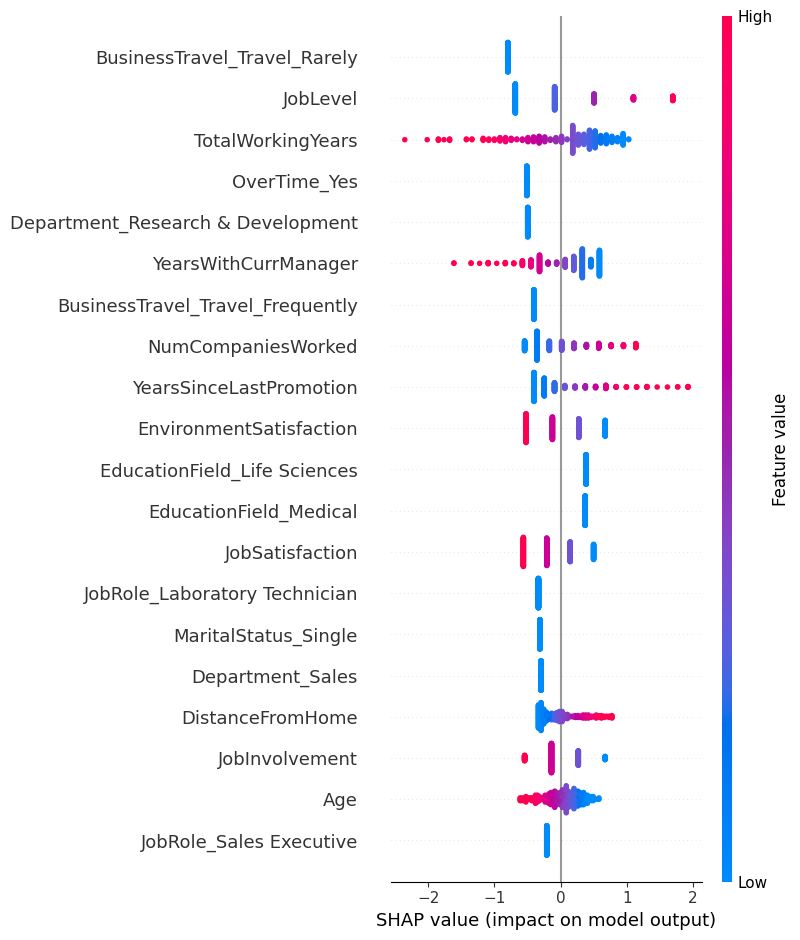

In [40]:
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled)


In [43]:
plt.savefig("outputs/shap_attrition_feature_importance.png", bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

🔍 Model Explainability Summary (SHAP Analysis)

This SHAP summary plot explains how and why the machine learning model predicts employee attrition.
It provides transparency by quantifying the impact of each feature on the model’s prediction.

📌 Key Takeaways from the SHAP Summary Plot

Features are ranked from most influential (top) to least influential (bottom) based on their overall contribution to attrition prediction.

Positive SHAP values increase the likelihood of attrition.

Negative SHAP values decrease the likelihood of attrition.

Red points represent higher feature values, while blue points represent lower feature values.

🧠 Major Drivers of Employee Attrition
⏱️ Overtime

Employees working overtime show strong positive SHAP values, indicating a significantly higher attrition risk.
This confirms that work-life imbalance is a primary driver of employee exits.

👶 Age & Career Stage

Younger employees (lower age, fewer total working years) are more likely to leave.

Experienced and senior employees demonstrate lower attrition risk.

This highlights the importance of early-career engagement and retention strategies.

🧑‍💼 Job Level & Tenure

Lower job levels and fewer years with the current manager increase attrition probability.

Stable reporting relationships and career growth reduce attrition risk.

🧪 Job Role Impact

Certain job roles—such as Laboratory Technicians and Sales Executives—show higher SHAP values, indicating a greater likelihood of attrition.
These roles may require targeted workload, compensation, or engagement interventions.

🚗 Distance from Home

Employees with longer commuting distances exhibit higher attrition risk, suggesting commute fatigue as an influential factor.

😊 Satisfaction & Engagement Metrics

Lower values of:

Job Satisfaction

Environment Satisfaction

Job Involvement

are associated with increased attrition risk, reinforcing the importance of employee engagement initiatives.

✅ Business Interpretation

The SHAP analysis validates earlier exploratory and statistical findings by clearly explaining why employees leave.
It enables HR leaders to:

Identify high-risk employees early

Understand the underlying reasons behind attrition predictions

Implement targeted, data-driven retention strategies

🎯 Conclusion

The SHAP explainability layer ensures that the attrition prediction model is:

Transparent

Trustworthy

Aligned with real-world HR dynamics

This makes the model suitable for business adoption, supporting proactive and informed HR decision-making.